In [1]:
import glob
import math
import datetime
from shapely.geometry import box, MultiPolygon

def do_the_thing (catchment_num, ens_num,event_num ):

    catchment_name  = CATCHMENT_LOOKUP_DICT[str(catchment_num)]
    boundary_gdf    = CATCHMENTS[CATCHMENTS['HA_NUM'] == str(catchment_num)]
    CATCHMENT_POLY = boundary_gdf.geometry.iloc[0]

    # Create a list which will store all results (across ensemble members)
    results = []

    # ───────────────────────────────────────────────── 
    # Create a mask for this catchment (over whole UK)
    # Create a version of it over the area filtered to the catchment
    # These are used later
    # ───────────────────────────────────────────────── 
    begin_time = time.time()
    full_rain_cube = get_rainfall_cube_subsection(2015, '01', f"/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/01/", 1, 2) #any year, any ensemble member
    FULL_MASK_2D   = mask_cube_with_catchment_full_grid(full_rain_cube[0], CATCHMENT_POLY, method='center_point')
    year_cube, mask_x_offset, mask_y_offset = subset_cube_to_bbox(full_rain_cube, CATCHMENT_POLY, buffer=0)
    ny_sub = year_cube.shape[1]
    nx_sub = year_cube.shape[2]
    mask_2d_sub = FULL_MASK_2D[mask_y_offset:mask_y_offset + ny_sub, 
                                mask_x_offset:mask_x_offset + nx_sub]
    del full_rain_cube, year_cube

    # ─────────────────────────────────────────────────
    # Get hydraulic conductivity data
    # ─────────────────────────────────────────────────
    HC_CUBE      = iris.load(f"/scratch/hydro4/users/kv25483/FutureFlood/Data/HydraulicConductivity/5km_{catchment_num}.nc")[0]
    HC_CUBE.data = np.where(FULL_MASK_2D, HC_CUBE.data, np.nan)
    HC_CUBE = filter_closer_to_catchment(HC_CUBE, CATCHMENT_POLY, plot=False)
    HC_DATA      = HC_CUBE.data  # realise once — shape (y, x)
    flood_dir    = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/PluvialResults/5km_total/Catchment_{catchment_num}/"

    # ─────────────────────────────────────────────────
    # HMM?
    # ─────────────────────────────────────────────────
    flood_numpy = {}  # will hold realised numpy arrays, keyed [depth]['area'/'vol']
    flood_cubes = {}  # still needed for maybe_diagnose (expects iris cubes)
    current_ens = None
    DIAGNOSE_EVENT = [0]
    n_days_ls      = [2, 3, 4, 5]
    all_results    = []

    # ───────────────────────────────────────────────── 
    # Loop over EMs (wrap in try/pass to deal with errors from mismatch of max precip)
    # ───────────────────────────────────────────────── 
    start_time_ens = time.time()
    # Create a list which will store all results from this ensemble member
    results_this_ens = []

    # Read in the csv with event details for this catchment/ensemble member
    rainfall_events  = pd.read_csv(RAINFALL_CSV_DIR + f"{catchment_name}_{ens_num}_full_events_with_event_nums.csv")
    rainfall_events['event_num']  = range(1, len(rainfall_events) + 1)
    rainfall_events['hydro_year'] = rainfall_events['start_year'].where(rainfall_events['start_month'] != 12,
            rainfall_events['start_year'] + 1)

    # Specify filepath to the directory with netCDF for this ensemble member
    rainfall_cube_dir = f"/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/{ens_num}/"

    # Create cached version of event details, for all events
    event_details_cache = {
        ev: get_rainfall_event_details(rainfall_events, ev)
        for ev in rainfall_events['event_num']}

    this_event = rainfall_events[rainfall_events['event_num']==event_num]['hydro_year']
    this_event.iloc[0]
    year = this_event.iloc[0]

    # ─────────────────────────────────────────────────
    sm_dir  = f'/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Soil_moisture/5km_regridded/Ens_{ens_num}/'
    sm_file = glob.glob(f"{sm_dir}/r001i1p*****_{year-1}1201-{year}1130_mrso.nc")[0]
    sm      = iris.load(sm_file)[0]

    # Check if we also need the previous hydro year's SM
    # (i.e. event peak is early December, so lookback window bleeds into Nov or earlier)
    needs_extra_sm = True

    if needs_extra_sm:
        # Load the prior hydro year file: Dec(yr-2) to Nov(yr-1)
        prev_sm_file = glob.glob(f"{sm_dir}/r001i1p*****_{year-2}1201-{year-1}1130_mrso.nc")
        if prev_sm_file:
            prev_sm = iris.load(prev_sm_file[0])[0]
            prev_sm.attributes = {}
            sm.attributes = {}
            sm = iris.cube.CubeList([prev_sm, sm]).concatenate_cube()
            print(f"  Loaded extra SM file for year {year-2}-{year-1} (early-December event)")
        else:
            print(f"  WARNING: needed prior SM file for {year-2}-{year-1} but not found")

    sm.data      = np.where(FULL_MASK_2D, sm.data, np.nan)
    sm           = filter_closer_to_catchment(sm, CATCHMENT_POLY, plot=False)
    sm_data      = sm.data
    sm_time_arr  = np.array([cell.point for cell in sm.coord('time').cells()])

    event_details = event_details_cache[event_num]

    # Get a portion of the cube, over the catchment, between the times when the maximum happened
    year_cube = get_rainfall_cube_subsection(year, ens_num, rainfall_cube_dir, 
                                         event_details['start_idx']-1, event_details['stop_idx'])
    year_cube.data = np.where(FULL_MASK_2D, year_cube.data, np.nan)
    year_cube, x_offset, y_offset = subset_cube_to_bbox(year_cube, CATCHMENT_POLY, buffer=0)
    # Extract the times for this subset
    time_coord  = year_cube.coord('time')

    # t0 = time_coord.units.num2date(time_coord.bounds[0, 0]) 
    t0 = time_coord.units.num2date(np.floor(time_coord.points[0]))
    t_end = time_coord.units.num2date(time_coord.points[-1])
    peak = cftime.Datetime360Day(event_details['yr'], event_details['month'], event_details['day'], event_details['hour'])
    peak_within_cube = t0 <= peak <= t_end

    # Find the location of the max precipitation value
    # This masks out all cells not inside the catchment
    this_event_results = find_max_precip_location_new(
        year_cube, event_details['start_idx'], event_details['stop_idx'],
        x_offset=x_offset, y_offset=y_offset, mask_2d=mask_2d_sub)

    # Add key details to the results dictionary
    this_event_results['ens']       = ens_num
    this_event_results['start_idx'] = event_details['start_idx']
    this_event_results['stop_idx']  = event_details['stop_idx']
    this_event_results['max_precip_from_csv']  = event_details['max_precip_from_csv']
    this_event_results['start_year']  = event_details['yr']
    this_event_results['month']  = event_details['month']
    this_event_results['event_num']  = event_details['event_num']
    if not peak_within_cube:
        this_event_results['time_mismatch'] = True
        print("TIME MISMACH")
    else:
        this_event_results['time_mismatch'] = False


    # Get the day on which the peak occurred
    # This uses t_local to reference the times from the subset
    t = time_coord.units.num2date(time_coord.points[this_event_results['t_local']])
    this_event_results['rainfall_peak_day'] = cftime.Datetime360Day(t.year, t.month, t.day)
    this_event_results['hydro_day_360'] = (
        (this_event_results['rainfall_peak_day'].month % 12) * 30
        + this_event_results['rainfall_peak_day'].day)
    this_event_results['day_360'] = (
        (this_event_results['rainfall_peak_day'].month - 1) * 30
        + this_event_results['rainfall_peak_day'].day)
    this_event_results['t_local_rebased']    = this_event_results['t_global'] - this_event_results['start_idx']

    # Get 1D cube, just at the location of the peak
    rainfall_at_peak  = get_data_at_peak_cell(year_cube, this_event_results, 'x_idx', 'y_idx')
    # Extract various temporal profile results
    if this_event_results['event_num'] in DIAGNOSE_EVENT:
        temp_profile_dict = find_temporal_profile_new(rainfall_at_peak, this_event_results, plot=True)
    else:
        temp_profile_dict = find_temporal_profile_new(rainfall_at_peak, this_event_results, plot=False)

    # Add these to dictionary of results 
    this_event_results.update(temp_profile_dict)    

    # Check whether the maximum precipitation matches the values in the input csv
    if not math.isclose(float(np.float32(this_event_results['max_precip'])), 
                         float(np.float32(this_event_results['max_precip_from_csv'])),
                         abs_tol=0.001):
        print(f"MISMATCH — ens={ens_num}, year={year}, event={event_num}")
        print(f"  cube: {this_event_results['max_precip']:.8f}")
        print(f"  csv:  {this_event_results['max_precip_from_csv']:.8f}")
        this_event_results['mismatch'] = True
    else:
        this_event_results['mismatch'] = False

        # ─────────────────────────────────────────────────
    # Do flood processing
    # -- Reload flood cubes only when ensemble member changes
    # ---- Otherwie just use the ones already loaded
    # ─────────────────────────────────────────────────
    if ens_num != current_ens:
        if flood_cubes:
            del flood_cubes, flood_numpy
            gc.collect()
        ens_flood_dir = f"{flood_dir}/Ens{ens_num}_{catchment_num}/"
        flood_cubes = {}
        flood_numpy = {}
        for depth in [10, 30]:
            area_cube = prepare_flood_cube(load_3d_cube(
                f"{ens_flood_dir}/{depth}cm/flooded_area_5km_total_Ens{ens_num}_{catchment_num}_{depth}cm.nc"))
            area_cube.data = np.where(FULL_MASK_2D, area_cube.data, np.nan)
            area_cube = filter_closer_to_catchment(area_cube, CATCHMENT_POLY, plot=False)
            vol_cube  = prepare_flood_cube(load_3d_cube(
                f"{ens_flood_dir}/{depth}cm/flooded_volume_5km_total_Ens{ens_num}_{catchment_num}_{depth}cm.nc"))
            vol_cube.data = np.where(FULL_MASK_2D, vol_cube.data, np.nan)
            vol_cube = filter_closer_to_catchment(vol_cube, CATCHMENT_POLY, plot=False)
            flood_cubes[depth] = {'area': area_cube, 'vol': vol_cube}  # iris, for diagnostics
            flood_numpy[depth] = {'area': area_cube.data, 'vol': vol_cube.data}  # numpy, for stats
        current_ens = ens_num     


    # ─────────────────────────────────────────────────
    # ── Diagnostics (still uses iris cubes for plotting) 
    # ─────────────────────────────────────────────────
    maybe_diagnose(
        this_event_results,
        event_num=this_event_results['event_num'],
        condition=(this_event_results['event_num'] in DIAGNOSE_EVENT),
        sm=sm,
        HC_CUBE=HC_CUBE,
        flood_cubes=flood_cubes,
        catchment_poly=CATCHMENT_POLY,
        ens_num=ens_num,
        rainfall_cube_dir=rainfall_cube_dir, 
        FULL_MASK_2D= FULL_MASK_2D)

    xi = int(this_event_results['x_idx'])
    yi = int(this_event_results['y_idx'])

    # ── SM stats — direct numpy indexing, no iris overhead ────────────────
    sm_at_peak_data   = sm_data[:, yi, xi]
    rainfall_peak_360 = this_event_results['rainfall_peak_day']

    mean_sm_stats = {}
    for n_days in n_days_ls:
        delta       = datetime.timedelta(days=n_days)
        mask        = (sm_time_arr >= (rainfall_peak_360 - delta)) & (sm_time_arr < rainfall_peak_360)
        subset_data = sm_at_peak_data[mask]

        if subset_data.size == 0:
            print(f"  Warning: empty SM window for event={row.event_num}, "
                  f"n_days={n_days}, peak={rainfall_peak_360}")
            mean_sm_stats[f'mean_sm_{n_days}_before_event'] = float('nan')
            continue

        mean_sm_stats[f'mean_sm_{n_days}_before_event'] = float(subset_data.mean())

    # ── Flood stats — direct numpy indexing ───────────────────────────────
    flood_stats = {}
    for depth in [10, 30]:
        flood_stats[f"{depth}cm_area"]   = flood_numpy[depth]['area'][this_event_results['event_num'] - 1, yi, xi]
        flood_stats[f"{depth}cm_volume"] = flood_numpy[depth]['vol'][this_event_results['event_num'] - 1, yi, xi]

    # ── HC stats — direct numpy indexing ─────────────────────────────────
    hc_stats = {'hc_at_peak': HC_DATA[yi, xi]}

    this_event_results.update(flood_stats)
    this_event_results.update(hc_stats)
    this_event_results.update(mean_sm_stats)

    # ------------
    if this_event_results['event_num'] in DIAGNOSE_EVENT:
        plot=True
    else:
        plot = False
    peak_results = analyse_peak_event(
            this_event_results,
            year_cube,
            flood_numpy,
            flood_cubes,
            CATCHMENT_POLY,
            boundary_gdf,
            neighbourhood_size=1,
            threshold_levels=[0.5, 0.6, 0.8],
            plot=True)

In [2]:
import os
import sys
import re
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from scipy import stats
import rioxarray as rxr

from Functions_AnalyseResults import partial_r2_for_catchment, plot_with_best_fit_line

sys.path.append('../ProcessEvents/')
from config import CATCHMENT_LOOKUP_DICT, OUT_DIR # MOLLY_DIR_FF, RAINFALL_CSV_DIR, ENSEMBLE_MEMBERS, , CATCHMENTS

sys.path.append('../../ProcessCatchments')
from functions import *
from functions_stage2 import (get_rainfall_cube_subsection, setup_worker_logger, find_max_precip_location_new, 
                        find_temporal_profile_new, maybe_diagnose, analyse_peak_event,
                             plot_cluster_check)

from config import RAINFALL_CSV_DIR, CATCHMENT_LOOKUP_DICT, OUT_DIR, CATCHMENTS, ENSEMBLE_MEMBERS 
from Functions_AnalyseResults import partial_r2_for_catchment, plot_with_best_fit_line

## Get a list of catchments which have flood outputs and rainfall detail outputs

In [3]:
all_catchments = set(CATCHMENT_LOOKUP_DICT.keys())

catchments_with_flood_output = []
for catchment_num in all_catchments:
    catchment_name = CATCHMENT_LOOKUP_DICT[catchment_num]
    fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails/Catchment_{catchment_num}/{catchment_name}.pkl"
    flood_fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/PluvialResults/5km_total/Catchment_{catchment_num}/Ens01_{catchment_num}/10cm/flooded_area_5km_total_Ens01_{catchment_num}_10cm.nc"
        
    if os.path.isfile(flood_fp) and os.path.isfile(fp):
        catchments_with_flood_output.append(catchment_num)
print(len(catchments_with_flood_output))

113


### Join together results for all these catchments, remove mismatched rows, add a catchment number flag

In [4]:
rainfall_events_all = []
for catchment_num in catchments_with_flood_output:
    catchment_name = CATCHMENT_LOOKUP_DICT[catchment_num]
    fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails/Catchment_{catchment_num}/{catchment_name}.pkl"
    rainfall_events = pd.read_pickle(fp)
    rainfall_events_complete = rainfall_events[rainfall_events['mismatch']!=True].copy()
    rainfall_events['catchment_num'] = catchment_num
    # print(f"Catchment {catchment_num} has {len(rainfall_events)}, of which {len(rainfall_events) - len(rainfall_events_complete)} are mismatched")
    rainfall_events_all.append(rainfall_events) 
rainfall_events_all_df = pd.concat(rainfall_events_all, ignore_index=True)    
rainfall_events_all_df.reset_index(inplace=True, drop = True)

In [ ]:
rainfall_events_all_df.to_pickle(f"/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails/all_catchments.pkl")

### Remove events with unrealistically high precipitation

In [5]:
rainfall_events_all_df = rainfall_events_all_df[rainfall_events_all_df['max_precip']<130].copy()

### Add variable describing length of event

In [6]:
rainfall_events_all_df['length'] = rainfall_events_all_df['times'].apply(len)

### Add variable classifying based on HC value

In [47]:
rainfall_events_all_df['HC_status'] = pd.cut(rainfall_events_all_df['hc_at_peak'],
    bins=[-float('inf'), 0.15, 1.1, 3, float('inf')],labels=['D', 'C', 'B', 'A'], right=False, include_lowest=True)

rainfall_events_all_df['HC_status_2'] = pd.cut(rainfall_events_all_df['hc_at_peak'],
    bins=[-float('inf'), 0.15, 0.3, 0.6, 1, 3, float('inf')],labels=['F', 'E', 'D', 'C', 'B', 'A'], right=False,
                                               include_lowest=True)


rainfall_events_all_df['HC_status'] = pd.cut(rainfall_events_all_df['hc_at_peak'],
    bins=[-float('inf'), 0.15, 1.1, 3, float('inf')],labels=['D', 'C', 'B', 'A'], right=False, include_lowest=True)

rainfall_events_all_df['HC_status_2'] = pd.cut(rainfall_events_all_df['hc_at_peak'],
    bins=[-float('inf'), 0.15, 0.3, 0.6, 1, 2, 3, float('inf')],labels=['G', 'F', 'E', 'D', 'C', 'B', 'A'], right=False,
                                               include_lowest=True)

### Investigate cells with no flooding

In [22]:
zero_frac = len(rainfall_events_all_df[rainfall_events_all_df['10cm_area'] == 0])/len(rainfall_events_all_df) * 100

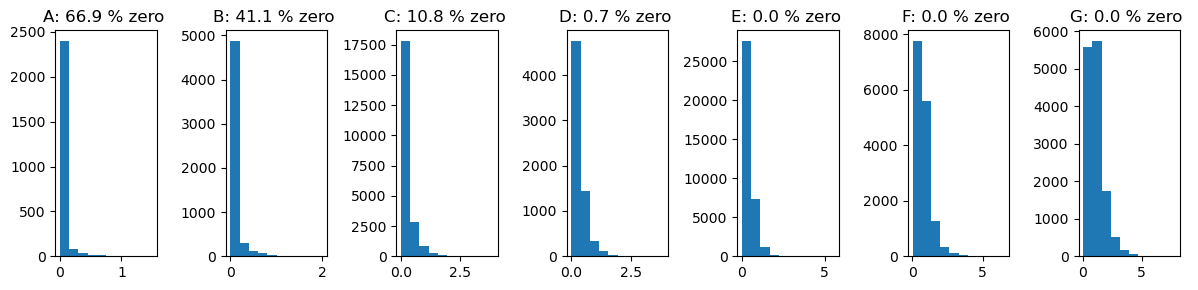

In [48]:
df= rainfall_events_all_df
fig, axs =plt.subplots(ncols=7, figsize=(12,3))
for i, cls in enumerate(sorted(df['HC_status_2'].unique())):
    sub = df[df['HC_status_2'] == cls]
    zero_frac = len(sub[sub['10cm_area'] == 0])/len(sub) * 100
    axs[i].hist(sub['10cm_area'], bins=10)
    axs[i].set_title(f"{cls}: {round(zero_frac,1)} % zero ")
fig.tight_layout()

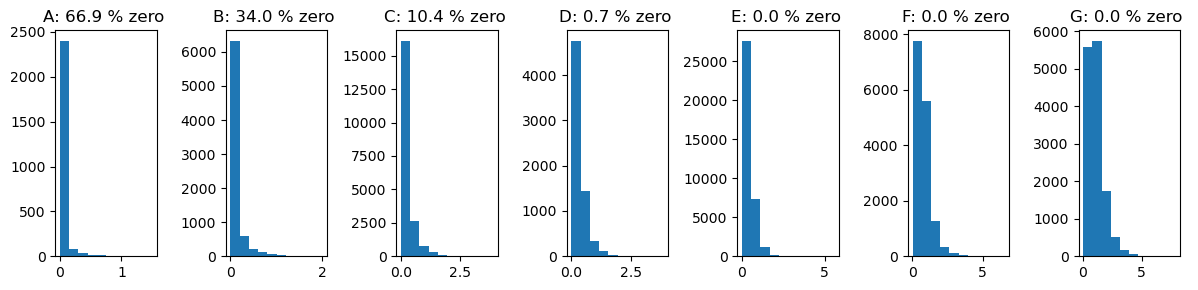

In [13]:
df= rainfall_events_all_df
fig, axs =plt.subplots(ncols=7, figsize=(12,3))
for i, cls in enumerate(sorted(df['HC_status_2'].unique())):
    sub = df[df['HC_status_2'] == cls]
    zero_frac = len(sub[sub['10cm_area'] == 0])/len(sub) * 100
    axs[i].hist(sub['10cm_area'], bins=10)
    axs[i].set_title(f"{cls}: {round(zero_frac,1)} % zero ")
fig.tight_layout()

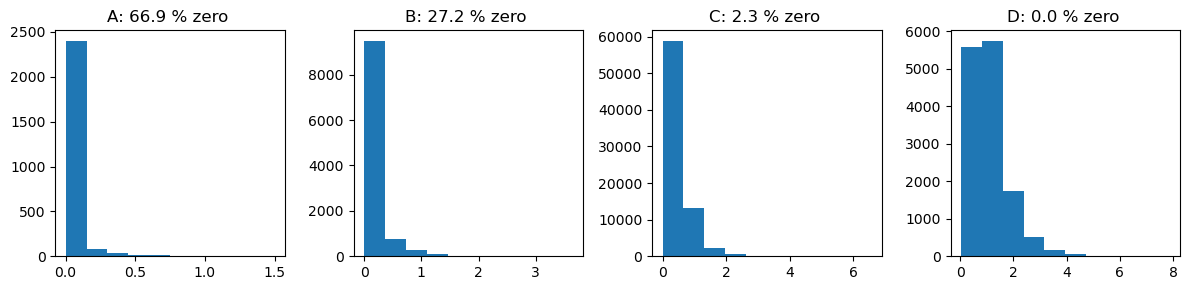

In [21]:
df= rainfall_events_all_df
fig, axs =plt.subplots(ncols=4, figsize=(12,3))
for i, cls in enumerate(sorted(df['HC_status'].unique())):
    sub = df[df['HC_status'] == cls]
    zero_frac = len(sub[sub['10cm_area'] == 0])/len(sub) * 100
    axs[i].hist(sub['10cm_area'], bins=10)
    axs[i].set_title(f"{cls}: {round(zero_frac,1)} % zero ")
fig.tight_layout()

### Plot the rainfall field at the peak timestep and the maximum flooding field for that event 

In [22]:
# --- Grid lines over the 5km rainfall grid ---
def add_grid_lines(ax, x_coord, y_coord, xlim=None, ylim=None, color='grey', lw=0.5, alpha=0.5):
    cellsize = 5000
    # cell edges = centres shifted by half a cell
    x_edges = np.concatenate([x_coord - cellsize/2, [x_coord[-1] + cellsize/2]])
    y_edges = np.concatenate([y_coord - cellsize/2, [y_coord[-1] + cellsize/2]])
    if xlim is not None:
        x_edges = x_edges[(x_edges >= xlim[0]) & (x_edges <= xlim[1])]
    if ylim is not None:
        y_edges = y_edges[(y_edges >= ylim[0]) & (y_edges <= ylim[1])]
    for xe in x_edges:
        ax.axvline(xe, color=color, linewidth=lw, alpha=alpha)
    for ye in y_edges:
        ax.axhline(ye, color=color, linewidth=lw, alpha=alpha)

In [38]:
rainfall_events_all_df.sort_values(by =['10cm_area']).head(10)[[ "event_num", "ens", "catchment_num", "start_year", "month", 
                                                                "max_precip", "total_acc",  
                                            "neighbourhood_rain_total","neighbourhood_n_cells",
                                            "10cm_area",
                                            "neighbourhood_flood_10_area", 
                                            "threshold_flood_10_area_t60",
                                            "threshold_flood_10_area_t80",
                                            "cluster_flood_10_area_t50",
                                           "cluster_flood_10_area_t80"]]

,event_num,ens,catchment_num,start_year,month,max_precip,total_acc,neighbourhood_rain_total,neighbourhood_n_cells,10cm_area,neighbourhood_flood_10_area,threshold_flood_10_area_t60,threshold_flood_10_area_t80,cluster_flood_10_area_t50,cluster_flood_10_area_t80
72958,35,04,106,2032,7.0,30.784100,42.748108,79.626639,9,0.0,0.0000,0.0000,0.0000,0.0000,0.0000
57569,91,08,8,2080,7.0,32.154339,47.318108,129.267354,6,0.0,0.0036,0.0036,0.0036,0.0036,0.0036
57570,92,08,8,2080,8.0,31.988359,61.710892,83.280527,7,0.0,0.0000,0.0000,0.0000,0.0000,0.0000
57856,28,13,8,2032,8.0,30.629885,58.959438,146.841229,9,0.0,0.0000,0.0000,0.0000,0.0000,0.0000
23544,78,05,86,2042,8.0,33.680683,42.297077,34.362075,3,0.0,0.0000,0.0000,0.0000,0.0000,0.0000
98624,23,15,74,2014,7.0,31.504990,60.856850,50.504823,4,0.0,0.0000,0.0000,0.0000,0.0000,0.0000
98625,24,15,74,2015,10.0,33.946686,94.013672,121.904465,6,0.0,0.0099,0.0045,0.0000,0.0099,0.0000
98626,25,15,74,2017,7.0,31.814690,37.879459,131.569035,6,0.0,0.0252,0.0117,0.0117,0.0603,0.0117
98627,26,15,74,2017,8.0,35.203484,38.537083,45.551022,4,0.0,0.1422,0.0000,0.0000,0.0000,0.0000
98634,33,15,74,2022,10.0,31.304897,45.833939,123.175694,6,0.0,0.0225,0.0504,0.0099,0.0558,0.0099


### Find all events with zero frac in one catchment

In [45]:
i = 57569

Catchment 8 | Event 91 | Max precip: 32.15433883666992
Peak index: 101 167
Value at peak: 32.15433883666992
Max in field: 32.15433883666992


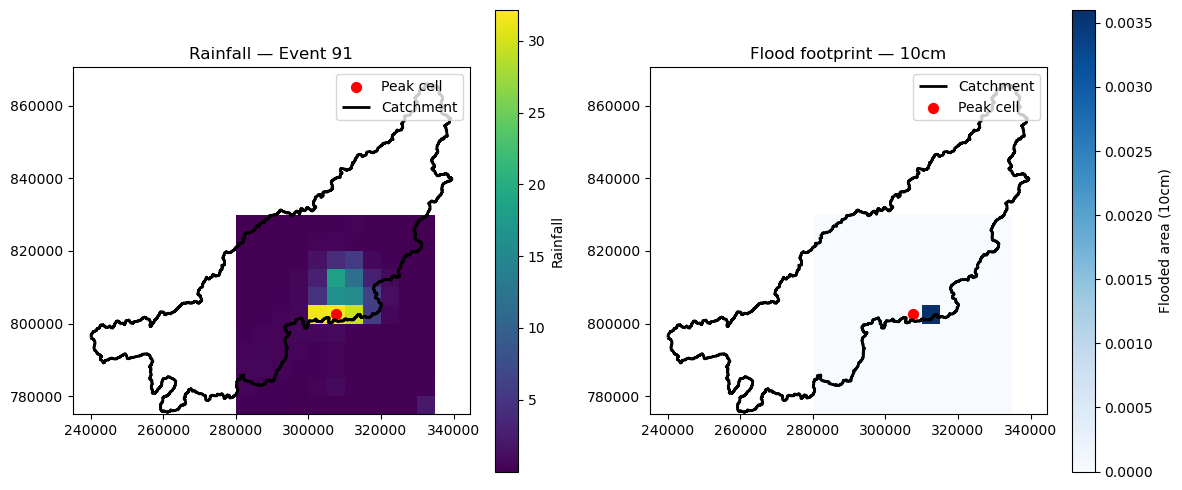

In [46]:
row = rainfall_events_all_df.loc[i]

ens = row['ens']
rainfall_cube_dir = f"/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/{ens}/"
year = int(row['start_year'])
catchment_num = row['catchment_num']

print(f"Catchment {row['catchment_num']} | Event {row['event_num']} | Max precip: {row['max_precip']}")

# Load cube (THIS defines the coordinate system)
year_cube = get_rainfall_cube_subsection(year,ens,rainfall_cube_dir,int(row['start_idx']) - 1,int(row['stop_idx']))

# Extract slice exactly like original code
t = int(row['t_local'])
rain = year_cube.data[t, :, :].astype(float)

# Clean (same as original)
rain = np.where((rain == -99999) | (rain > 1e19), np.nan, rain)

ny, nx = rain.shape

# Peak indices 
yi = int(row['y_idx_global'])
xi = int(row['x_idx_global'])

print("Peak index:", xi, yi)
print("Value at peak:", rain[yi, xi])
print("Max in field:", np.nanmax(rain))

# Window (same logic as original)
pad = 5

y0 = max(0, yi - pad)
y1 = min(ny, yi + pad + 1)

x0 = max(0, xi - pad)
x1 = min(nx, xi + pad + 1)

sub = rain[y0:y1, x0:x1]

# Relative peak position
peak_x = xi - x0
peak_y = yi - y0

boundary_gdf = CATCHMENTS[CATCHMENTS['HA_NUM'] == str(catchment_num)] 
CATCHMENT_POLY = boundary_gdf.geometry.iloc[0]

x_coord = year_cube.coord('projection_x_coordinate').points
y_coord = year_cube.coord('projection_y_coordinate').points

x_sub = x_coord[x0:x1]
y_sub = y_coord[y0:y1]

########
depth = 10  # or loop over [10, 30]

flood_dir    = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/PluvialResults/5km_total/Catchment_{catchment_num}/"
ens_flood_dir = f"{flood_dir}/Ens{ens}_{catchment_num}/"

area_cube = prepare_flood_cube(load_3d_cube(
    f"{ens_flood_dir}/{depth}cm/flooded_area_5km_total_Ens{ens}_{catchment_num}_{depth}cm.nc"))

# Find the index matching this event's number via the coord, not a positional guess
event_coord_vals = area_cube.coord('event number').points
flood_t = np.where(event_coord_vals == row['event_num'])[0]
if len(flood_t) == 0:
    raise ValueError(f"event_num {row['event_num']} not found in area_cube event_number coord")
flood_t = flood_t[0]

flood_data = area_cube.data[flood_t, :, :].astype(float)
flood_data = np.where((flood_data == -99999) | (flood_data > 1e19), np.nan, flood_data)

flood_x = area_cube.coord('projection_x_coordinate').points
flood_y = area_cube.coord('projection_y_coordinate').points

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Rainfall subplot ---
ax0 = axes[0]
im0 = ax0.pcolormesh(x_sub, y_sub, sub, shading='auto', cmap='viridis')
plt.colorbar(im0, ax=ax0, label="Rainfall")
ax0.scatter(x_coord[xi], y_coord[yi], color='red', s=50, label='Peak cell')
boundary_gdf.boundary.plot(ax=ax0, color='black', linewidth=2, label='Catchment')
ax0.legend()
ax0.set_title(f"Rainfall — Event {row['event_num']}")

# --- Flood footprint subplot, same window as rainfall since grids match ---
ax1 = axes[1]
# find indices into flood_x/flood_y matching x_sub/y_sub bounds
fx0 = np.searchsorted(flood_x, x_sub.min())
fx1 = np.searchsorted(flood_x, x_sub.max()) + 1
fy0 = np.searchsorted(flood_y, y_sub.min())
fy1 = np.searchsorted(flood_y, y_sub.max()) + 1

im1 = ax1.pcolormesh(flood_x[fx0:fx1], flood_y[fy0:fy1],
                      flood_data[fy0:fy1, fx0:fx1],
                      shading='auto', cmap='Blues')
plt.colorbar(im1, ax=ax1, label=f"Flooded area ({depth}cm)")
boundary_gdf.boundary.plot(ax=ax1, color='black', linewidth=2, label='Catchment')
ax1.scatter(x_coord[xi], y_coord[yi], color='red', s=50, label='Peak cell')
ax1.legend()
ax1.set_title(f"Flood footprint — {depth}cm")

# xlim = ax0.get_xlim()
# ylim = ax0.get_ylim()
# add_grid_lines(ax0, x_coord, y_coord, xlim=xlim, ylim=ylim)
# add_grid_lines(ax1, x_coord, y_coord, xlim=xlim, ylim=ylim)

plt.tight_layout()
plt.show()

8 08 91 6 3 4
  Loaded extra SM file for year 2078-2079 (early-December event)
Area cube shape: (92, 19, 20)
Area cube shape: (92, 19, 20)


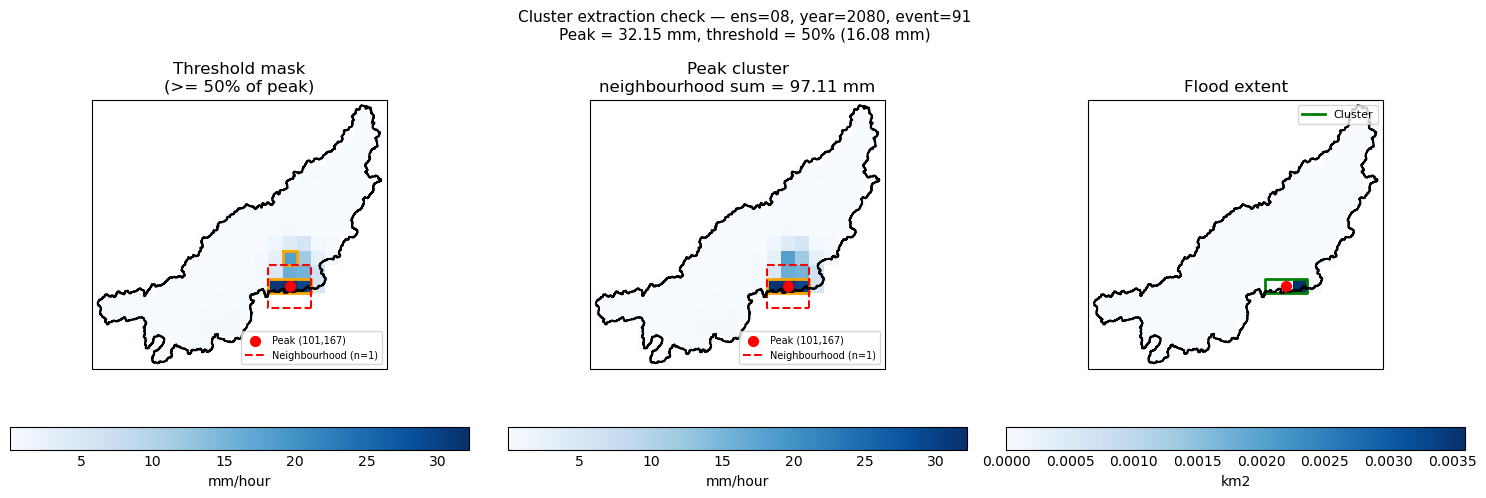

In [48]:
this_event = rainfall_events_all_df.loc[i]
print(this_event['catchment_num'], this_event['ens'], this_event['event_num'], this_event['neighbourhood_n_cells'],
     this_event['cluster_n_cells_t50'], this_event['threshold_n_cells_t50'])
do_the_thing(this_event['catchment_num'], this_event['ens'], this_event['event_num'])

DEM CRS: EPSG:27700
Sink CRS: EPSG:27700
Rainfall cube likely CRS: check year_cube.coord_system()
Fraction of 30m pixels flagged as sink/river within peak cell: 2.31%
Slope within peak cell — mean: 11.3°, max: 35.7°
Catchment-wide slope — mean: 9.1°, median: 7.5°


/home/kv25483/anaconda3/envs/geo_env2/lib/python3.10/site-packages/geopandas/plotting.py:480: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  ax.figure.canvas.draw_idle()
/tmp/ipykernel_240041/4181799227.py:63: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


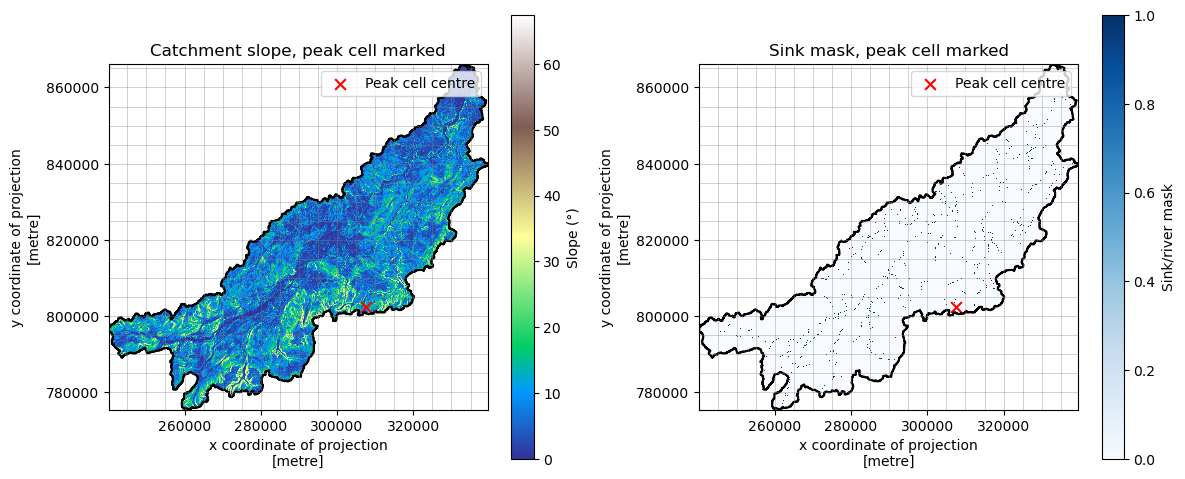

In [49]:
# --- Load DEM and sink mask ---
dem_path = f"/scratch/hydro4/users/la17355/FUTURE-FLOOD/Data/Model_builds/Pluvial/v4/dem/dem_filled_30m_{catchment_num}.tif"
dem_da = rxr.open_rasterio(dem_path, masked=True).squeeze()

sink_path = f"/scratch/hydro4/users/la17355/FUTURE-FLOOD/Data/Model_builds/Pluvial/v4/pluvial_sink_mask/pluvial_sink_mask_30m_{catchment_num}.tif"
sink_da = rxr.open_rasterio(sink_path, masked=True).squeeze()

print("DEM CRS:", dem_da.rio.crs)
print("Sink CRS:", sink_da.rio.crs)
print("Rainfall cube likely CRS: check year_cube.coord_system()")

# --- Compute slope (degrees) from DEM using its own resolution ---
res_x, res_y = dem_da.rio.resolution()  # should be ~30, -30
dz_dy, dz_dx = np.gradient(dem_da.values, abs(res_y), abs(res_x))
slope_rad = np.arctan(np.sqrt(dz_dx**2 + dz_dy**2))
slope_deg = np.degrees(slope_rad)
slope_da = dem_da.copy(data=slope_deg)

# --- Define the 5km peak cell's bounding box in real coordinates ---
# Need the cell's actual extent, not just its centre — assumes regular 5km grid
cellsize = 5000  # confirm this matches your rainfall cube resolution
cx, cy = x_coord[xi], y_coord[yi]
cell_xmin, cell_xmax = cx - cellsize/2, cx + cellsize/2
cell_ymin, cell_ymax = cy - cellsize/2, cy + cellsize/2

# --- Clip DEM/slope/sink mask to that 5km cell footprint ---
sink_cell = sink_da.rio.clip_box(cell_xmin, cell_ymin, cell_xmax, cell_ymax)
slope_cell = slope_da.rio.clip_box(cell_xmin, cell_ymin, cell_xmax, cell_ymax)

# --- Diagnostics ---
sink_vals = sink_cell.values
sink_frac = np.nanmean(sink_vals > 0)  # adjust threshold once you know what the mask codes mean
print(f"Fraction of 30m pixels flagged as sink/river within peak cell: {sink_frac:.2%}")

slope_vals = slope_cell.values
print(f"Slope within peak cell — mean: {np.nanmean(slope_vals):.1f}°, max: {np.nanmax(slope_vals):.1f}°")

# --- Compare to catchment-wide context ---
slope_catchment = slope_da.rio.clip([CATCHMENT_POLY], drop=True)
print(f"Catchment-wide slope — mean: {float(slope_catchment.mean()):.1f}°, "
      f"median: {float(slope_catchment.median()):.1f}°")

# --- Visualise ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
slope_da.rio.clip([CATCHMENT_POLY], drop=True).plot(ax=axes[0], cmap='terrain', cbar_kwargs={'label': 'Slope (°)'})
axes[0].scatter(cx, cy, color='red', s=60, marker='x', label='Peak cell centre')
boundary_gdf.boundary.plot(ax=axes[0], color='black', linewidth=1.5)
axes[0].legend()
axes[0].set_title("Catchment slope, peak cell marked")

sink_da.rio.clip([CATCHMENT_POLY], drop=True).plot(ax=axes[1], cmap='Blues', cbar_kwargs={'label': 'Sink/river mask'})
axes[1].scatter(cx, cy, color='red', s=60, marker='x', label='Peak cell centre')
boundary_gdf.boundary.plot(ax=axes[1], color='black', linewidth=1.5)
axes[1].legend()
axes[1].set_title("Sink mask, peak cell marked")

# apply to the slope/sink subplots, restricted to the catchment extent shown
xlim = axes[0].get_xlim()
ylim = axes[0].get_ylim()
add_grid_lines(axes[0], x_coord, y_coord,  xlim=xlim, ylim=ylim)
add_grid_lines(axes[1], x_coord, y_coord,  xlim=xlim, ylim=ylim)

plt.tight_layout()
plt.show()